<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/lunar_SARSAsemi.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# SARSA Semigradiente con tilings en el problema LunarLander-v3

*Description*: Implementación y análisis del algoritmo SARSA Semi-gradiente utilizando aproximación de funciones mediante tilings para resolver el problema LunarLander-v3.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno

In [1]:
import sys
if 'google.colab' in sys.modules:
    # Definimos que el entorno es Colab
    en_colab = True
    print("Ejecutando en Google Colab")
else:
    # Definimos que el entorno es local
    en_colab = False
    print("Ejecutando en entorno local")

if en_colab:
    #@title Copiar el repositorio.
    print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
    !git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
    !cd EML_Carrillo_Ibarrola_Palomar/

    #@title Importamos todas las clases y funciones
    # Añadir los directorio fuentes al path de Python
    sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src')
    # Verificar que se han añadido correctamente
    print(sys.path)

    !pip install -r ./EML_Carrillo_Ibarrola_Palomar/requirements.txt

    dir_base = "./EML_Carrillo_Ibarrola_Palomar/entornos_complejos"
else:
    import os
    sys.path.append(os.path.abspath("src"))
    dir_base = ".."

Ejecutando en Google Colab
Clonando el repositorio, tiempo estimado: 1-2 minutos...
fatal: destination path 'EML_Carrillo_Ibarrola_Palomar' already exists and is not an empty directory.
['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src']


In [2]:
from tqdm import tqdm
import random
import numpy as np
import gymnasium as gym
from agents import TileCodingEnv, LunarAgentSARSA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Experimento

En este experimento buscamos evaluar el rendimiento del algoritmo de discretización de tile coding, aplicado sobre un algoritmo SARSA semigradiente en el entorno  **LunarLander-v3**, que se describirá a continuación.

Para lograr este objetivo, realizaremos las siguientes pruebas y visualizaciones para cada método:
- Ajuste de hiperparámetros de nñumero de bins y número de episodios.
- Heatmap de recompensa media, porcentaje de éxito y desviación estándar para distintos valores de los parámetros.
- Gráfica de recompensas, longitud de episodio y error diferencial
- Visualización del agente en distintas etapas del entrenamiento

## Descripción del entorno

Los experimentos se llevarán a cabo en el entorno de Gymnasium **LunarLander-v3**, un problema clásico de **aprendizaje por refuerzo con espacio de estados continuo**.

Este entorno modela el problema de **optimización de trayectoria de un módulo lunar**, donde el agente debe aprender a controlar los motores para realizar un aterrizaje seguro en la plataforma situada en la coordenada $(0,0)$.

El entorno se caracteriza por:

* **Espacio de estados**. Vector continuo de 8 dimensiones (float32) que representa:
  * Posición del módulo en $x$ y $y$
  * Velocidad lineal en $x$ y $y$
  * Ángulo del módulo
  * Velocidad angular
  * Dos variables booleanas que indican si cada pata está en contacto con el suelo

* **Espacio de acciones**. Consta de 4 acciones discretas:
  * 0: no hacer nada
  * 1: activar motor lateral izquierdo
  * 2: activar motor principal
  * 3: activar motor lateral derecho

* **Recompensa.** En cada paso se otorga una recompensa basada en varios factores:
  * Aumenta cuanto más cerca está el módulo de la plataforma
  * Aumenta cuanto menor es la velocidad
  * Disminuye cuanto más inclinado está el módulo
  * $+10$ puntos por cada pata en contacto con el suelo
  * $-0.03$ por motor lateral
  * $-0.3$ por motor principal
  * $+100$ si el aterrizaje es seguro
  * $-100$ si el módulo se estrella

* **Terminación del episodio**. Un episodio finaliza cuando:
  * el módulo se estrella contra la superficie lunar
  * el módulo sale del área visible
  * el sistema detecta que el módulo ha quedado en reposo tras aterrizar

Un episodio se considera resuelto si obtiene una recompensa total $\geq 200$.

### Tile Coding con SARSA Semigradiente

El método de tile coding busca transformar las observaciones continuas del entorno en observaciones discretas, mediante la subdivisión de sus rangos en múltiples bins. Se trata es una técnica de discretización de observaciones que 
divide el espacio de estados en múltiples tilings superpuestos. Cada tiling es 
una partición del espacio de observaciones. Las observaciones continuas se 
representan mediante un vector de caracteristicas, y se elige la siguiente acción 
usando una política $\epsilon$-greedy basada en la función de valor aproximada mediante SARSA.

A continuación definimos el método de entrenamiento del agente:

In [3]:

def train_agent_SARSA(agent, n_episodes, saving=False):
    env = agent.env

    for n in tqdm(range(n_episodes)):
        obs, info = env.reset(seed = SEED if n == 0 else None)
        done = False

        # Play one complete episode
        action = agent.get_action(obs)

        while not done:
            next_obs, reward, terminated, truncated, info = env.step(action)

            next_action = agent.get_action(next_obs)

            # Update Q-values (Semigradient SARSA)
            agent.update(obs, action, reward, terminated, next_obs, next_action)

            # Move to next state
            done = terminated or truncated
            obs = next_obs
            action = next_action

        # Reduce exploration rate (agent becomes less random over time)
        agent.decay_epsilon()

## Ajuste de hiperparámetros

Comenzamos realizando un ajuste de hiperparámetros en las dos variables que creemos que pueden tener mayor impacto en la efectividad del entrenamiento:

- Número de bins para las 6 variables continuas de LunarLander.
- Número de episodios de entrenamiento.

Las dos variables binarias (contacto de patas) se mantienen siempre en 2 bins, y no serán alteradas por el tile coding, puesto que ya son discretas.

Mostramos heatmaps de recompensa media, tasa de éxito y desviación estándar.

In [4]:
import os
import seaborn as sns
import matplotlib.pyplot as plt


def grid_search_lunar_bins_episodes(
    bins_values,
    n_episodes_list,
    n_tilings=8,
    learning_rate=0.2,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    ratio=0.8,
    test_episodes=200,
):
    win_rates = np.zeros((len(bins_values), len(n_episodes_list)))
    avg_rewards = np.zeros((len(bins_values), len(n_episodes_list)))
    std_rewards = np.zeros((len(bins_values), len(n_episodes_list)))

    best_params = None
    best_avg_reward = -np.inf

    for i, n_bins in enumerate(bins_values):
        bins_cfg = np.array([n_bins, n_bins, n_bins, n_bins, n_bins, n_bins, 2, 2])

        for j, n_eps in enumerate(n_episodes_list):
            base_env_gs = gym.make("LunarLander-v3")
            tc_env = TileCodingEnv(
                base_env_gs,
                low=base_env_gs.observation_space.low,
                high=base_env_gs.observation_space.high,
                bins=bins_cfg,
                n_tilings=n_tilings,
            )
            env_gs = gym.wrappers.RecordEpisodeStatistics(tc_env, buffer_length=n_eps)
            env_gs.bins = bins_cfg
            env_gs.n_tilings = n_tilings

            agent_gs = LunarAgentSARSA(
                env=env_gs,
                learning_rate=learning_rate,
                initial_epsilon=initial_epsilon,
                epsilon_decay=(initial_epsilon - final_epsilon) / (n_eps * ratio),
                final_epsilon=final_epsilon,
                decay_type="linear",
            )

            train_agent_SARSA(agent_gs, n_eps)
            win_rate, avg_reward, std_reward = agent_gs.test(num_episodes=test_episodes)

            win_rates[i, j] = win_rate
            avg_rewards[i, j] = avg_reward
            std_rewards[i, j] = std_reward

            if avg_reward > best_avg_reward:
                best_avg_reward = avg_reward
                best_params = {
                    "bins_continuos": n_bins,
                    "n_episodes": n_eps,
                    "win_rate": win_rate,
                    "avg_reward": avg_reward,
                    "std_reward": std_reward,
                }

            env_gs.close()
            base_env_gs.close()

    return win_rates, avg_rewards, std_rewards, best_params



In [5]:
%%capture
# Parrilla de búsqueda
bins_values = [4, 6, 8, 10]
n_episodes_list = [2000, 5000, 8000, 11000]

win_rates, avg_rewards, std_rewards, best_params = grid_search_lunar_bins_episodes(
    bins_values=bins_values,
    n_episodes_list=n_episodes_list,
    n_tilings=8,
    learning_rate=0.2,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    ratio=0.8,
    test_episodes=200,
)


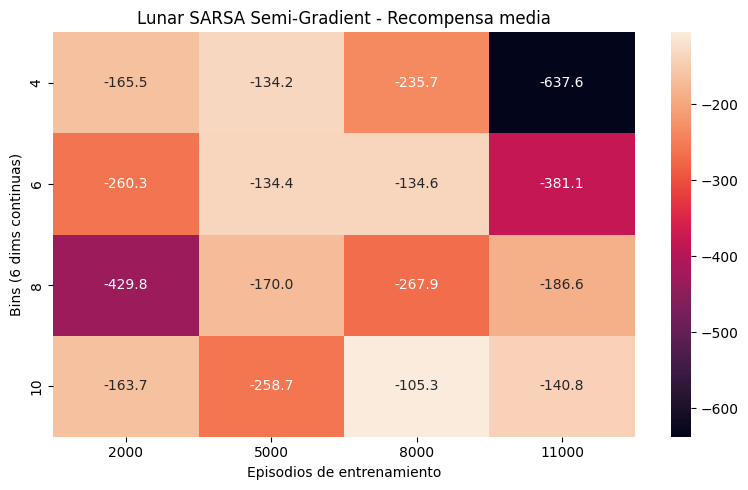

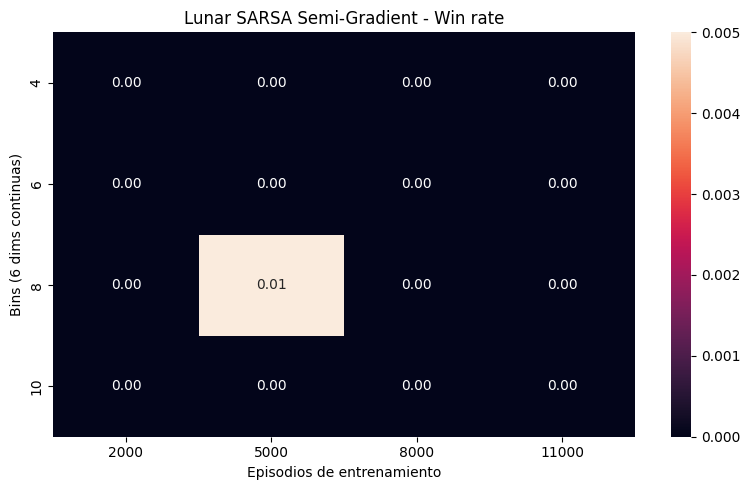

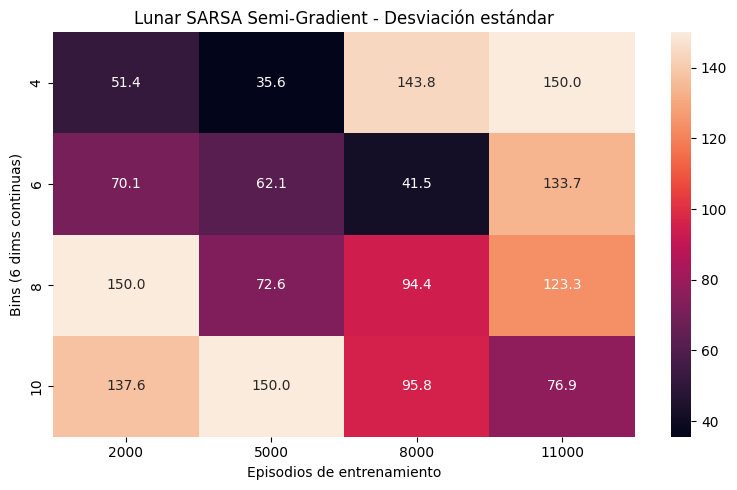

In [6]:

# Guardado opcional de figuras
out_dir = dir_base + "/data/results/SARSAsemi"
os.makedirs(out_dir, exist_ok=True)

plt.figure(figsize=(8, 5))
sns.heatmap(
    avg_rewards,
    annot=True,
    fmt=".1f",
    xticklabels=n_episodes_list,
    yticklabels=bins_values,
)
plt.title("Lunar SARSA Semi-Gradient - Recompensa media")
plt.xlabel("Episodios de entrenamiento")
plt.ylabel("Bins (6 dims continuas)")
plt.tight_layout()
plt.savefig(out_dir + "/grid_bins_episodes_avg_reward_heatmap.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(
    win_rates,
    annot=True,
    fmt=".2f",
    xticklabels=n_episodes_list,
    yticklabels=bins_values,
)
plt.title("Lunar SARSA Semi-Gradient - Win rate")
plt.xlabel("Episodios de entrenamiento")
plt.ylabel("Bins (6 dims continuas)")
plt.tight_layout()
plt.savefig(out_dir + "/grid_bins_episodes_win_rate_heatmap.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(
    np.minimum(std_rewards, 150),
    annot=True,
    fmt=".1f",
    xticklabels=n_episodes_list,
    yticklabels=bins_values,
)
plt.title("Lunar SARSA Semi-Gradient - Desviación estándar")
plt.xlabel("Episodios de entrenamiento")
plt.ylabel("Bins (6 dims continuas)")
plt.tight_layout()
plt.savefig(out_dir + "/grid_bins_episodes_std_heatmap.png")
plt.show()

Estos resultados muestran que este ataque es insuficiente para el aprendizaje en este entorno. En ninguno de los tres heatmaps se aprecia un patrón claro, lo que hace pensar que el agente apenas está aprendiendo, y los resultados obtenidos son observaciones de variables aleatorias con varianza muy grande. Cabría entonces esperar que otra ejecución arrojara unos resultados muy distintos, pero igualmente malos (esto se ha comprobado empíricamente, al cambiar la semilla, los resultados varían enormemente). Entrenaremos de nuevo el modelo con mejor recompensa media (10 bins por dimensión y 8000 episodios), pero a sabiendas de que los resultados que obtendremos no serán buenos.

100%|██████████| 8000/8000 [14:19<00:00,  9.30it/s]


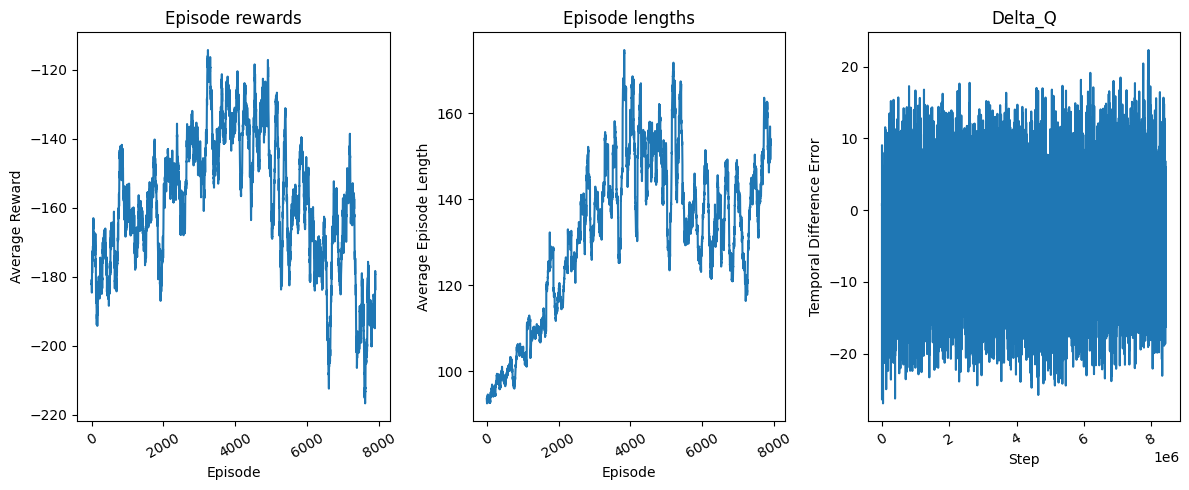

In [7]:

# ----- CONFIGURACIÓN Y EJECUCIÓN -----
n_episodes = 8000
learning_rate = 0.2
# # Creamos el entorno original y lo envolvemos en nuestro Tile Coder
base_env = gym.make("LunarLander-v3")
# # 4 bins por cada una de las 8 dimensiones
bins = np.array([10, 10, 10, 10, 10, 10, 2, 2])  # número de intervalos por dimensión
n_tilings = 8
env = TileCodingEnv(base_env, low=base_env.observation_space.low, high=base_env.observation_space.high, bins=bins, n_tilings=n_tilings)

# # Utilizamos RecordEpisodeStatistics para el tracking (requiere acceder a env.unwrapped.return_queue)
# env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

initial_epsilon = 1.0
final_epsilon = 0.05
ratio = 0.8 # Exploramos durante el 80% del entrenamiento

# agent = LunarAgentSARSA(
#     env=env,
#     learning_rate=learning_rate,
#     initial_epsilon=initial_epsilon,
#     epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
#     final_epsilon=final_epsilon,
#     decay_type="linear"
# )
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
env.bins = bins
env.n_tilings = n_tilings
# 4. Envolvemos para estadísticas
#env = gym.wrappers.RecordEpisodeStatistics(saenv, buffer_length=n_episodes)

# 5. Pasamos el entorno al agente
# El agente ahora podrá acceder a n_tilings si lo modificamos ligeramente
# o si usamos las variables que ya extrajimos.
agent = LunarAgentSARSA(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=initial_epsilon,
    epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
    final_epsilon=final_epsilon,
    decay_type="linear"
)

saved_episodes = train_agent_SARSA(agent, n_episodes, saving=True)

import utils
utils.plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=100)


In [8]:
agent.test()

Test Results over 1000 episodes:
Win Rate: 0.9%
Average Reward: -181.059
Standard Deviation: 136.398


(np.float64(0.009),
 np.float64(-181.05922183543035),
 np.float64(136.39787655338247))

Podemos ver en las gráficas y en los resultados del test que el agente es incapaz de aprender. De hecho, la recompensa media final es inferior a la inicial. Estos resultados son debidos a la excesiva complejidad del entorno en comparación a la gran simplicidad de la técnica utilizada y, sobre todo, a la alta dimensionalidad del espacion de observaciones. Un método de discretización como tile coding puede arrojar buenos resultados en un problema como **Mountain-Car**, donde el espacio de observaciones es bidimensional. En este caso trabajamos con 8 dimensiones, 6 de las cuales son continuas. Si subdividimos estas dimensiones en un número pequeño de bins, nos falta resolución a la hora de desarrollar una política eficaz. Si, por el contrario, tratamos de aumentar el número de bins, nos encontramos con que el cardinal de nuestro espacio de observaciones ha crecido exponencialmente. El número de estados sobre los que aprender una política es ahora demasiado alto y cada uno es visitado solo unas pocas veces a lo largo de todo el entrenamiento.

Mostraremos, por último, un gif de la nave tratando de aterrizar:

In [9]:
import gymnasium as gym
import numpy as np

def visualize_solution(agent, bins, n_tilings, env_name="LunarLander-v3", seed=None):
    # Creamos el entorno base con render
    base_env = gym.make(env_name, render_mode="human")

    # Envolvemos con Tile Coding si bins fueron proporcionados
    if bins is not None:
        # Extraemos los límites del espacio de observación del entorno base
        low = base_env.observation_space.low
        high = base_env.observation_space.high

        # Pasamos low, high, y usamos 'n' en lugar de 'n_tilings'
        tile_env = TileCodingEnv(base_env, bins=bins, low=low, high=high, n_tilings = n_tilings)
    else:
        tile_env = base_env  # si no usamos Tile Coding

    # Recordamos estadísticas (opcional)
    env = gym.wrappers.RecordEpisodeStatistics(tile_env, buffer_length=1)

    obs, info = env.reset(seed=seed)
    done = False
    total_reward = 0
    step_count = 0

    while not done:
        # obs ya está en formato Tile Coding si usamos tile_env
        action = agent.get_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count += 1

    print(f"Total reward del episodio visualizado: {total_reward:.2f}")
    env.close()

# ----- USO -----
# Reutiliza los bins y n_tilings que usaste para entrenar
visualize_solution(agent, bins=bins, n_tilings=n_tilings)

Total reward del episodio visualizado: -645.41


In [10]:
import imageio
import base64
from IPython.display import HTML
def run_episode_greedy_lunarlander(agent, env, max_steps=1000):
    frames = []
    obs, _ = env.reset()
    agent.epsilon = 0.0  # Forzamos a ser completamente greedy

    for _ in range(max_steps):
        frame = env.render()
        frames.append(frame)

        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        obs = next_obs

        if terminated or truncated:
            frames.append(env.render())
            break

    return frames

def frames_to_gif(frames, filename=dir_base+"/data/results/SARSAsemi/lunarlander_sarsa.gif"):
    with imageio.get_writer(filename, mode='I') as writer:
        for frame in frames:
            writer.append_data(frame)
    return filename

def display_gif(gif_path):
    with open(gif_path, 'rb') as f:
        video = f.read()
    b64 = base64.b64encode(video)
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

GIF guardado en: ./EML_Carrillo_Ibarrola_Palomar/entornos_complejos/data/results/SARSAsemi/lunarlander_sarsa2.gif



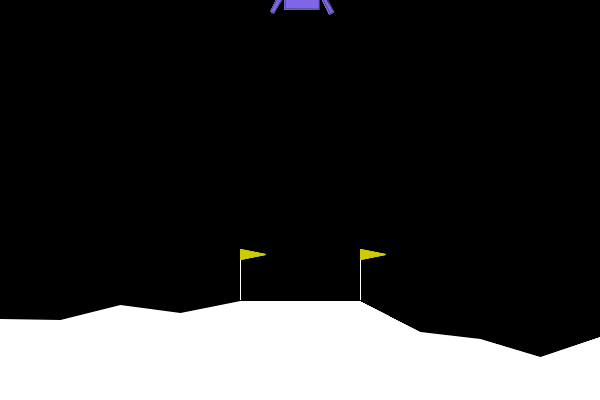

In [11]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')
env_demo = TileCodingEnv(env_demo, bins=bins, low=env_demo.observation_space.low, high=env_demo.observation_space.high, n_tilings=n_tilings)
state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Ejecutar episodio greedy
frames = run_episode_greedy_lunarlander(agent, env_demo, max_steps=1000)

env_demo.close()

# Crear GIF
gif_path = frames_to_gif(frames, filename=dir_base+"/data/results/SARSAsemi/lunarlander_sarsa2.gif")
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)